# Sample Selection and Normality Model Building

This notebook first loads the dataset obtained after removing highly correlated features with the KPI. Next, the methodology uses various steps to extract samples that describe normal network behavior. This sequence of steps also allows us to identify performance outliers and anomalies. Then, the routine builds an XGBoost regression model that characterizes normal network behavior. In this case, we need the ``xgboost`` library to construct the regression model.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Ploting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import PyOD models
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.models.gmm import GMM
from pyod.models.kde import KDE
from pyod.models.cblof import CBLOF
from pyod.models.cof import COF
from pyod.models.hbos import HBOS
from pyod.models.sod import SOD
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from pyod.models.loda import LODA
from pyod.models.deep_svdd import DeepSVDD

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

from sklearn.metrics import jaccard_score
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import make_scorer, f1_score

import statsmodels.api as sm
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

This stage loads the dataset obtained after removing the features that are highly correlated to the KPI.

In [2]:
print('-----------------------------------------')
print('LOADING DATASET A FILE DOWNLOAD DATASET')
data_file = 'd2_Operator1_CapacityDL_clean'
data = pd.read_csv('data/clean_data/' + data_file + '.csv', sep=",", decimal='.', low_memory = False)
print('Data Size:(%d, %d)'%(data.shape[0], data.shape[1]))
print('-----------------------------------------')
target_kpi = 'transfer.datarate'
# target_kpi = 'test.throughput.kbit.s'
kpi_aux    = data[target_kpi]
data.describe()

-----------------------------------------
LOADING DATASET A FILE DOWNLOAD DATASET
Data Size:(1001, 120)
-----------------------------------------


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,...,abs.segmentsizes.25.,abs.segmentsizes.50.,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1.001000e+03,1.001000e+03
mean,128.041958,23504.771229,19.445554,0.000999,645.926074,2.017982,2.334520e+06,1028.684316,62737.201798,231.181818,...,2597.134615,6170.843157,1.137196e+05,203.033966,0.000159,63.993007,236.949051,6.736559e+09,3.329800e+13,3.934347e+05
std,95.049736,11232.441681,35.021355,0.031607,3311.848603,46.315242,7.746871e+06,4453.186531,8786.050549,9.141931,...,457.538529,1642.232733,6.787134e+05,577.700565,0.000095,159.287303,1485.634821,1.424162e+10,2.990747e+13,1.984722e+05
min,0.000000,1299.000000,5.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,5308.000000,64.000000,...,660.000000,1327.000000,5.538000e+03,0.000000,0.000080,0.000000,0.000000,2.317959e+00,9.010940e+00,2.408967e+03
25%,62.000000,18357.000000,6.000000,0.000000,0.000000,0.000000,0.000000e+00,32.000000,65236.000000,232.000000,...,2776.000000,5552.000000,6.523600e+04,0.000000,0.000080,0.000000,0.000000,9.986515e+02,6.019258e+04,2.530839e+05
50%,117.000000,23260.000000,9.000000,0.000000,23.000000,0.000000,1.081380e+05,75.000000,65236.000000,232.000000,...,2776.000000,6940.000000,6.523600e+04,37.000000,0.000160,13.000000,3.000000,2.691650e+09,3.004338e+13,3.813481e+05
75%,176.000000,27219.000000,17.000000,0.000000,185.000000,0.000000,1.393763e+06,322.000000,65236.000000,232.000000,...,2776.000000,6940.000000,6.523600e+04,173.000000,0.000240,53.000000,26.000000,7.241105e+09,5.818665e+13,5.196789e+05
max,748.000000,105106.000000,521.000000,1.000000,31047.000000,1397.000000,8.789408e+07,41515.000000,65236.000000,232.000000,...,4164.000000,9716.000000,1.389992e+07,9177.000000,0.000400,1956.000000,15336.000000,1.970290e+11,1.836066e+14,1.275028e+06


## Performance Outlier and Anomaly Detection

### Outliers in the KPI

In [3]:
data = data.loc[:,data.columns != target_kpi]
data[target_kpi] = np.log10(kpi_aux)

data_nrm = data[target_kpi].to_numpy() / np.std(data[target_kpi])
Q3 = np.quantile(data_nrm, 0.75) - np.mean(data_nrm)
if (Q3 != 0):
    med = np.median(data[target_kpi])
    MAD = (1/Q3) * np.median(np.absolute(data[target_kpi] - med))
    outliers_kpi = (data[target_kpi] > med + 3.0*MAD)|(data[target_kpi] < med - 3.0*MAD)
print('Outlier Rate in KPI: %.4f'%(np.mean(outliers_kpi)))

atypical = pd.DataFrame(columns=['outliers'])
atypical['outliers'] = outliers_kpi
# atypical.to_csv('data/FileDL_outliers.csv')
# atypical.to_csv('data/LivePageDL_outliers.csv')

Outlier Rate in KPI: 0.0420


#### Comparison with other outlier detectors using the same outlier rate

1 fitting IForest
2 fitting KNN
3 fitting LOF
4 fitting PCA
5 fitting GMM
6 fitting KDE
7 fitting OCSVM
8 fitting CBLOF
9 fitting COF
10 fitting HBOS
11 fitting COPOD
12 fitting ECOD
13 fitting LODA


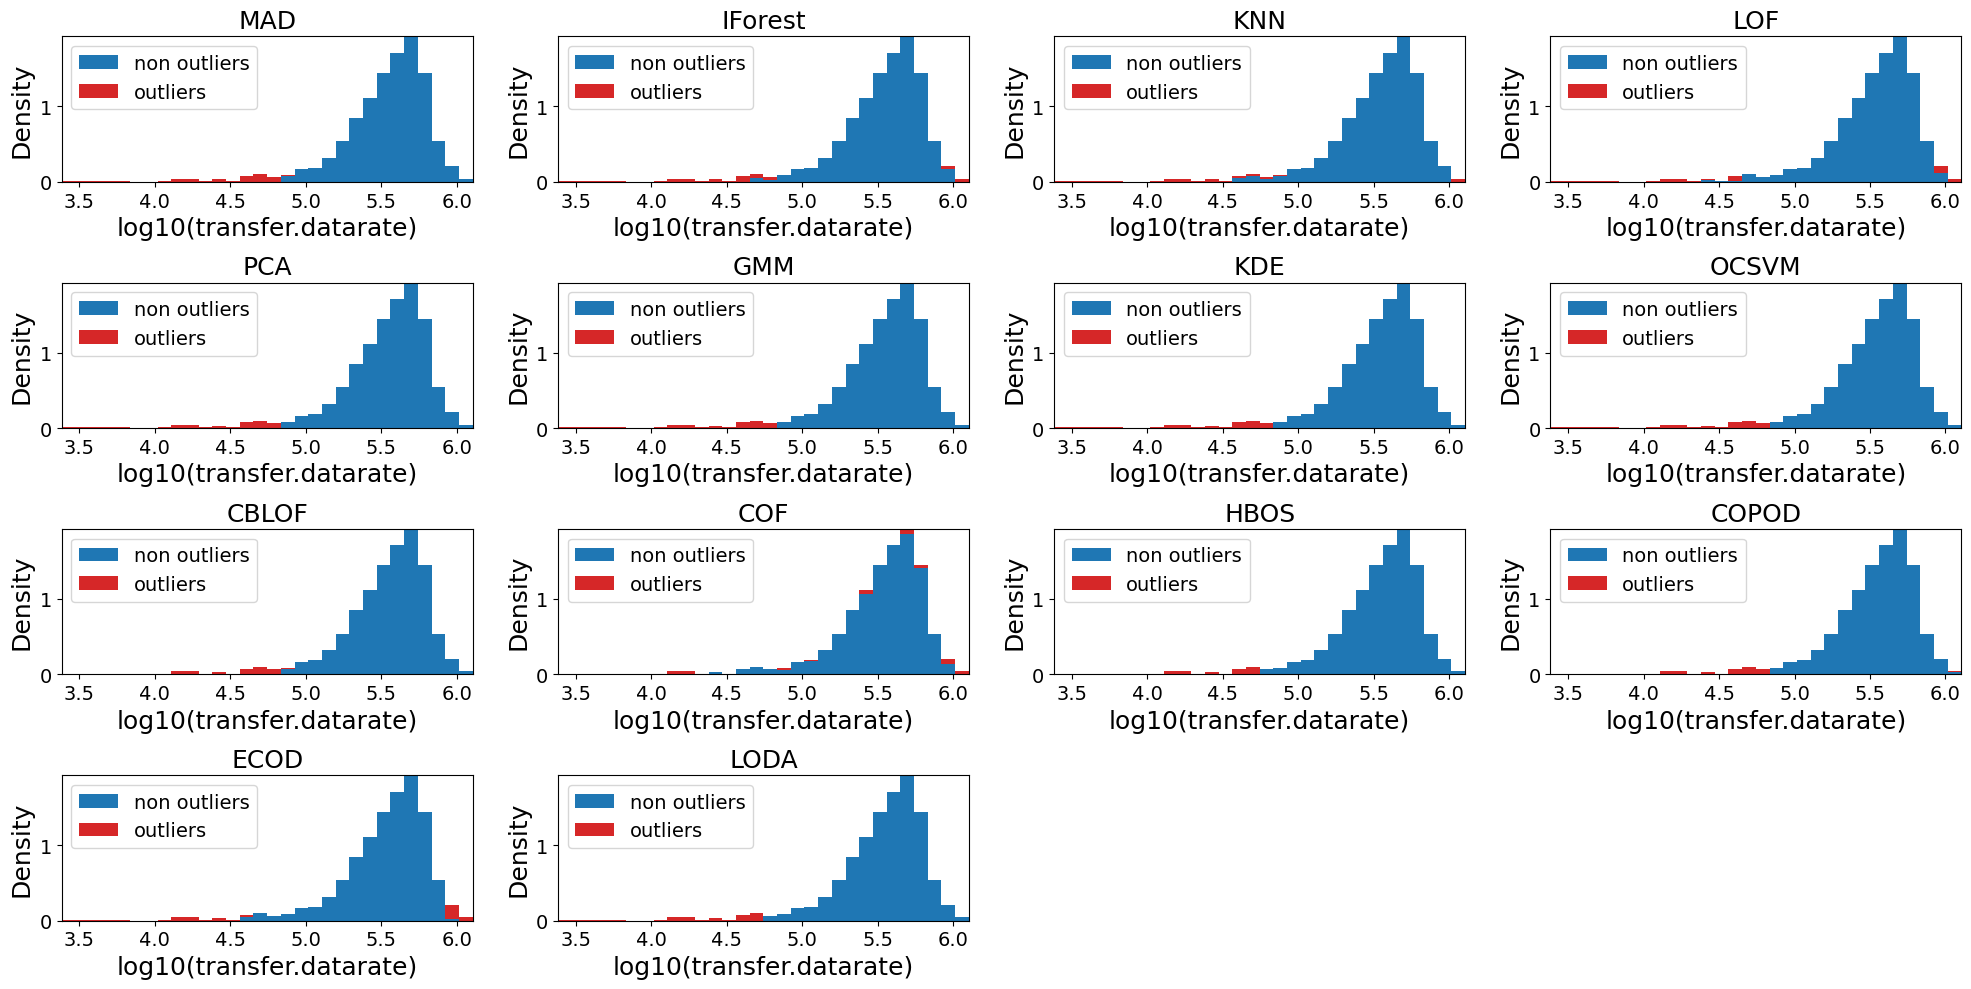

,method,sensitivity,specificity,f1-score,precision,jaccard
0,IForest,0.809524,0.992701,0.819277,0.829268,0.693878
1,KNN,0.595238,0.994786,0.694444,0.833333,0.531915
2,LOF,0.52381,0.987487,0.578947,0.647059,0.407407
3,PCA,1.0,1.0,1.0,1.0,1.0
4,GMM,1.0,1.0,1.0,1.0,1.0
5,KDE,1.0,1.0,1.0,1.0,1.0
6,OCSVM,1.0,1.0,1.0,1.0,1.0
7,CBLOF,1.0,1.0,1.0,1.0,1.0
8,COF,0.357143,0.971846,0.357143,0.357143,0.217391
9,HBOS,0.833333,1.0,0.909091,1.0,0.833333


In [4]:
outlier_rate = np.mean(outliers_kpi)
random_state = 42
classifiers ={'IForest': IForest(contamination = outlier_rate,
                                          bootstrap = True,
                                          random_state = random_state),
              'KNN':      KNN(contamination=outlier_rate),
	          'LOF':      LOF(n_neighbors=35, 
                              contamination=outlier_rate),
              'PCA':      PCA(contamination=outlier_rate, 
                              random_state=random_state),
	          'GMM':      GMM(contamination=outlier_rate,
							  random_state=random_state),
	          'KDE':      KDE(contamination=outlier_rate),
              'OCSVM':    OCSVM(contamination=outlier_rate,
                                kernel='poly',
                                degree=3),
              'CBLOF':    CBLOF(contamination=outlier_rate,
			                    check_estimator=False, 
                                random_state=random_state),
              'COF':      COF(contamination=outlier_rate,
                              n_neighbors=35,),
              'HBOS':     HBOS(n_bins='auto',
                               contamination=outlier_rate),
              'COPOD':    COPOD(contamination=outlier_rate),
              'ECOD':     ECOD(contamination=outlier_rate),
              'LODA':     LODA(contamination=outlier_rate),
}

ncols = 4
nrows = (len(classifiers))//ncols + 1
fig = plt.figure(figsize=(nrows*5,10), tight_layout=True)

anomaly_classes = np.unique(outliers_kpi)
ax = fig.add_subplot(nrows,ncols,1)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab10")[0],sns.color_palette("tab10")[3]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('MAD', fontsize=18)
plt.autoscale(axis='both', tight=True)


comparison = pd.DataFrame(columns=['method','sensitivity','specificity','f1-score','precision','jaccard'])
X = data.iloc[:, data.columns == target_kpi]
for i, (clf_name, clf) in enumerate(classifiers.items()):
    print(i + 1, 'fitting', clf_name)
    clf.fit(X)
    y_pred = clf.predict(X)
    comparison.at[i,'method'] = clf_name
    comparison.at[i,'sensitivity'] = recall_score(outliers_kpi, y_pred)
    comparison.at[i,'specificity'] = recall_score(outliers_kpi, y_pred, pos_label=0)
    comparison.at[i,'f1-score']    = f1_score(outliers_kpi, y_pred)
    comparison.at[i,'precision']   = precision_score(outliers_kpi, y_pred)
    comparison.at[i,'jaccard']     = jaccard_score(outliers_kpi, y_pred)


    anomaly_classes = np.unique(y_pred)
    ax = fig.add_subplot(nrows,ncols,i+2)
    ax.hist([data[target_kpi].to_numpy()[y_pred == j] for j in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab10")[0],sns.color_palette("tab10")[3]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
    plt.tick_params(axis='both', labelsize=14)
    plt.legend(fontsize=14)
    plt.xlabel('log10(transfer.datarate)', fontsize=18)
    plt.ylabel('Density', fontsize=18)
    plt.title(clf_name, fontsize=18)
    plt.autoscale(axis='both', tight=True)
plt.show()
comparison

### Outliers in Features

In [5]:
data = data.loc[:,data.columns != target_kpi]
data[target_kpi] = np.log10(kpi_aux)

scaler    = StandardScaler()
detector0 = OneClassSVM(gamma='auto', kernel='poly', degree=3).fit(scaler.fit_transform(data))
anomaly0  = detector0.predict(scaler.fit_transform(data))
if (np.sum(anomaly0 == 1) > np.sum(anomaly0 == -1)):
    anomaly0 = -anomaly0
outliers_features = (anomaly0 == 1)

# mad_coeff = 3
# data1 = data.copy()
# data1['N_outlier'] = 0
# for col in data1.columns:
#     if (col != 'N_outlier'):
#         data_nrm = data1[col]/data1[col].std()
#         Q3 = data_nrm.quantile(0.75) - data_nrm.median()
#         if (Q3 != 0):
#             med = data1[col].median()
#             dev = data1[col] - med
#             MAD = (1/Q3) * dev.abs().median()
#             if (MAD != 0):
#                 data1.loc[(data1[col]<= med - (mad_coeff * MAD)) | (data1[col]>= med + (mad_coeff * MAD)), 'N_outlier'] += 1  
# outliers_features = (data1["N_outlier"] != 0)
outlier_feature_rate = np.mean(outliers_features)
print('Outlier Rate in Features: %.2f%%'%(100*np.mean(outliers_features)))

Outlier Rate in Features: 41.56%


1 fitting IForest
2 fitting KNN
3 fitting LOF


Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x79027499bbc0>>
Traceback (most recent call last):
  File "/home/juan/anaconda3/envs/adtest/lib/python3.12/site-packages/xgboost/core.py", line 637, in _next_wrapper
    return self._handle_exception(lambda: self.next(input_data), 0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/juan/anaconda3/envs/adtest/lib/python3.12/site-packages/xgboost/core.py", line 550, in _handle_exception
    return fn()
           ^^^^
  File "/home/juan/anaconda3/envs/adtest/lib/python3.12/site-packages/xgboost/core.py", line 637, in <lambda>
    return self._handle_exception(lambda: self.next(input_data), 0)
                                          ^^^^^^^^^^^^^^^^^^^^^
  File "/home/juan/anaconda3/envs/adtest/lib/python3.12/site-packages/xgboost/data.py", line 1402, in next
    input_data(**self.kwargs)
  File "/home/juan/anaco

4 fitting PCA
5 fitting GMM
6 fitting KDE
7 fitting CBLOF
8 fitting COF
9 fitting HBOS
10 fitting COPOD
11 fitting ECOD
12 fitting LODA
13 fitting SOD
14 fitting DeepSVDD
Epoch 1/100, Loss: 35.44459143280983
Epoch 2/100, Loss: 36.47165337204933
Epoch 3/100, Loss: 35.7202807366848
Epoch 4/100, Loss: 36.20633101463318
Epoch 5/100, Loss: 35.45997565984726
Epoch 6/100, Loss: 35.800792813301086
Epoch 7/100, Loss: 36.85734084248543
Epoch 8/100, Loss: 35.6797850728035
Epoch 9/100, Loss: 35.79900377988815
Epoch 10/100, Loss: 35.66881537437439
Epoch 11/100, Loss: 35.8523034453392
Epoch 12/100, Loss: 35.94704481959343
Epoch 13/100, Loss: 36.03406313061714
Epoch 14/100, Loss: 35.48017376661301
Epoch 15/100, Loss: 35.59218057990074
Epoch 16/100, Loss: 35.388221085071564
Epoch 17/100, Loss: 36.10250160098076
Epoch 18/100, Loss: 35.500666707754135
Epoch 19/100, Loss: 40.26670104265213
Epoch 20/100, Loss: 36.036923974752426
Epoch 21/100, Loss: 35.43295568227768
Epoch 22/100, Loss: 35.42963397502899
E

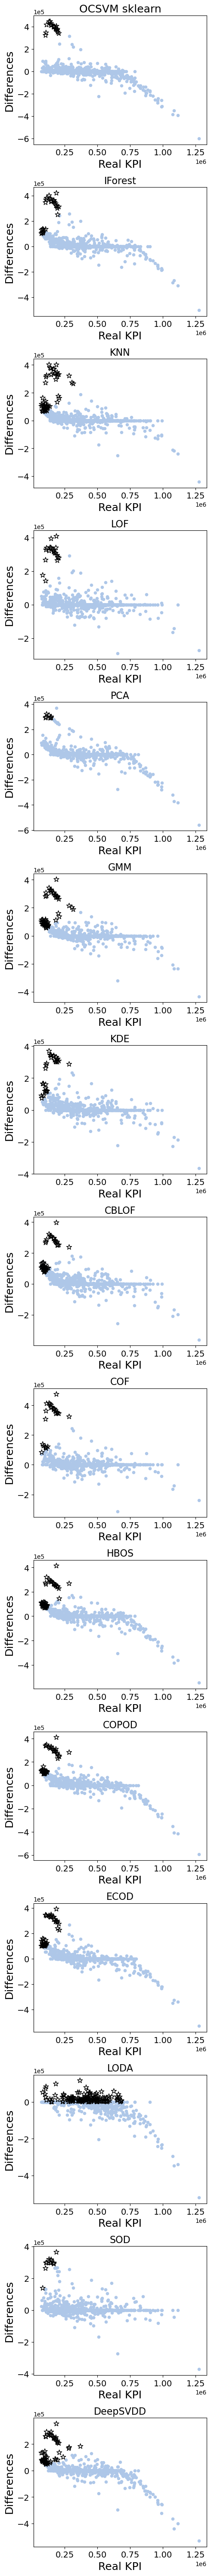

,method,sensitivity,specificity,f1-score,precision,jaccard
0,IForest,1.0,0.991489,0.826087,0.703704,0.703704
1,KNN,1.0,0.96383,0.527778,0.358491,0.358491
2,LOF,1.0,0.997872,0.95,0.904762,0.904762
3,PCA,0.368421,1.0,0.538462,1.0,0.368421
4,GMM,1.0,0.956383,0.481013,0.316667,0.316667
5,KDE,1.0,0.98617,0.745098,0.59375,0.59375
6,CBLOF,1.0,0.97234,0.59375,0.422222,0.422222
7,COF,1.0,0.991489,0.826087,0.703704,0.703704
8,HBOS,1.0,0.969149,0.567164,0.395833,0.395833
9,COPOD,1.0,0.976596,0.633333,0.463415,0.463415


In [6]:
data_normality  = data.copy()
data_normality  = data[~(outliers_features|outliers_kpi)]
data_normality[target_kpi] = kpi_aux[~(outliers_features|outliers_kpi)].to_numpy().reshape(-1, 1)

train_cols = data_normality.columns[data_normality.columns != target_kpi]
X_train    = data_normality.loc[:, train_cols]
y_train    = data_normality[target_kpi].to_numpy().reshape(-1, 1) 

model_normality = xgb.XGBRegressor()
model_normality.fit(X_train, y_train)
y_predicted     = model_normality.predict(data[train_cols])

# Linear model on training data
data[target_kpi]      = kpi_aux
y_train_linear_model1 = sm.add_constant(data[target_kpi][~(outliers_features|outliers_kpi)])
linear_model1         = sm.OLS(y_predicted[~(outliers_features|outliers_kpi)], 
                               y_train_linear_model1).fit()

unsupervised_classifiers ={'IForest': IForest(contamination = outlier_feature_rate,
                                          bootstrap = True,
                                          random_state = random_state),
              'KNN':      KNN(contamination=outlier_feature_rate),
	          'LOF':      LOF(n_neighbors=35, 
                              contamination=outlier_feature_rate),
              'PCA':      PCA(contamination=outlier_feature_rate, 
                              random_state=random_state),
	          'GMM':      GMM(contamination=outlier_feature_rate,
							  random_state=random_state),
	          'KDE':      KDE(contamination=outlier_feature_rate),
              # 'OCSVM':    OCSVM(contamination=outlier_feature_rate,
              #                   kernel='poly',
              #                   gamma='auto',
              #                   degree=3),
              'CBLOF':    CBLOF(contamination=outlier_feature_rate,
			                    check_estimator=False, 
                                random_state=random_state),
              'COF':      COF(contamination=outlier_feature_rate,
                              n_neighbors=35,),
              'HBOS':     HBOS(n_bins='auto',
                               contamination=outlier_feature_rate),
              'COPOD':    COPOD(contamination=outlier_feature_rate),
              'ECOD':     ECOD(contamination=outlier_feature_rate),
              'LODA':     LODA(contamination=outlier_feature_rate),
              'SOD':      SOD(contamination=outlier_feature_rate),
              'LODA':     LODA(contamination=outlier_feature_rate),
              'DeepSVDD': DeepSVDD(n_features=data.shape[1],
                                   contamination=outlier_feature_rate),
}


# ncols = 2
# nrows = len(unsupervised_classifiers) + 1
# fig = plt.figure(figsize=(10,nrows*4), tight_layout=True)
# ax = fig.add_subplot(nrows,2,1)
# plt.scatter(data[target_kpi][~(outliers_features|outliers_kpi)], 
#             y_predicted[~(outliers_features|outliers_kpi)], 
#             color=sns.color_palette("tab20")[1], 
#             s=50, 
#             marker = 'o')
# plt.plot([np.min(y_train), np.max(y_train)], 
#             [(linear_model1.params[1] * np.min(y_train) + linear_model1.params[0]), (linear_model1.params[1] * np.max(y_train) + linear_model1.params[0])],
#             '--',
#             color = 'k',
#             linewidth=3,
#             label = 'y_pred = %.2f * y_real + %.2f'%(linear_model1.params[1], linear_model1.params[0]))
# plt.xscale('log')
# plt.yscale('log')
# plt.tick_params(axis='both', labelsize=14)
# plt.xlabel('Real KPI (kbps)', fontsize=16)
# plt.ylabel('Predicted KPI (kbps)', fontsize=16)
# plt.title('OC-SVM sklearn', fontsize=16)
# plt.legend(fontsize=14)

# ax  = fig.add_subplot(nrows,2,2)
# plt.scatter(data[target_kpi][~(outliers_features|outliers_kpi)], 
#             y_predicted[~(outliers_features|outliers_kpi)], 
#             color=sns.color_palette("tab20")[1], 
#             s=50, 
#             marker = 'o',
#             label = 'Train')
# plt.scatter(data[target_kpi][outliers_features&(~outliers_kpi)], 
#             y_predicted[outliers_features&(~outliers_kpi)], 
#             s=100, 
#             marker = '*', 
#             color= 'k', 
#             label='Outliers in features', 
#             facecolors='none')
# plt.xscale('log')
# plt.yscale('log')
# plt.tick_params(axis='both', labelsize=14)
# plt.xlabel('Real KPI (kbps)', fontsize=16)
# plt.ylabel('Predicted KPI (kbps)', fontsize=16)
# plt.title('Outlier Rate: %.2f%%'%(100*np.mean(outliers_features)), fontsize=16)
# plt.legend(fontsize=14)
# fig.tight_layout()


y_difference_log10 = (np.log10(y_predicted) - np.log10(kpi_aux)).to_numpy().reshape(-1,1)
y_difference       = (y_predicted - kpi_aux).to_numpy().reshape(-1,1)
anomaly_detector   = OneClassSVM(gamma='auto', kernel='poly', degree=3).fit(y_difference_log10[~outliers_kpi])
anomalies = anomaly_detector.predict(y_difference_log10[~outliers_kpi])
if (np.sum(anomalies == 1) > np.sum(anomalies == -1)):
    anomalies = -anomalies
anomalies = (anomalies==1)
anomalies_original = anomalies

kpi_aux_anm = kpi_aux[~outliers_kpi]
y_difference_anm = y_difference[~outliers_kpi]

ncols = 1
nrows = len(unsupervised_classifiers) + 1
fig = plt.figure(figsize=(5,nrows*4), tight_layout=True)
ax = fig.add_subplot(nrows,1,1)
plt.scatter(kpi_aux_anm[anomalies==False], y_difference_anm[anomalies==False], color=sns.color_palette("tab20")[1], s=20, label='Normality')
plt.scatter(kpi_aux_anm[anomalies==True], y_difference_anm[anomalies==True], color='k', marker='*', facecolors='none', s=80, label='Anomalies')
plt.xlabel('Real KPI', fontsize=18)
plt.ylabel('Differences', fontsize=18)
plt.title('OCSVM sklearn', fontsize=18)
plt.tick_params(axis='both', labelsize=14)
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

compare_unsup     = pd.DataFrame(columns=['method','sensitivity','specificity','f1-score','precision','jaccard'])
compare_anomalies = pd.DataFrame(columns=['method','sensitivity','specificity','f1-score','precision','jaccard'])
scaler    = StandardScaler()
X = scaler.fit_transform(data)
for i, (clf_name, clf) in enumerate(unsupervised_classifiers.items()):
    print(i + 1, 'fitting', clf_name)
    clf.fit(X)
    y_pred = clf.predict(X)
    compare_unsup.at[i,'method'] = clf_name
    compare_unsup.at[i,'sensitivity'] = recall_score(outliers_features, y_pred)
    compare_unsup.at[i,'specificity'] = recall_score(outliers_features, y_pred, pos_label=0)
    compare_unsup.at[i,'f1-score']    = f1_score(outliers_features, y_pred)
    compare_unsup.at[i,'precision']   = precision_score(outliers_features, y_pred)
    compare_unsup.at[i,'jaccard']     = jaccard_score(outliers_features, y_pred)

    data_normality  = data.copy()
    data_normality  = data[~(y_pred|outliers_kpi)]
    data_normality[target_kpi] = kpi_aux[~(y_pred|outliers_kpi)].to_numpy().reshape(-1, 1)

    train_cols = data_normality.columns[data_normality.columns != target_kpi]
    X_train    = data_normality.loc[:, train_cols]
    y_train    = data_normality[target_kpi].to_numpy().reshape(-1, 1) 

    model_normality = xgb.XGBRegressor()
    model_normality.fit(X_train, y_train)
    y_predicted     = model_normality.predict(data[train_cols])

    # Linear model on training data
    data[target_kpi]      = kpi_aux
    y_train_linear_model1 = sm.add_constant(data[target_kpi][~(y_pred|outliers_kpi)])
    linear_model1         = sm.OLS(y_predicted[~(y_pred|outliers_kpi)], 
                               y_train_linear_model1).fit()

    y_difference_log10 = (np.log10(y_predicted) - np.log10(kpi_aux)).to_numpy().reshape(-1,1)
    y_difference       = (y_predicted - kpi_aux).to_numpy().reshape(-1,1)
    anomaly_detector   = OneClassSVM(gamma='auto', kernel='poly', degree=3).fit(y_difference_log10[~outliers_kpi])
    anomalies = anomaly_detector.predict(y_difference_log10[~outliers_kpi])
    if (np.sum(anomalies == 1) > np.sum(anomalies == -1)):
        anomalies = -anomalies
    anomalies = (anomalies==1)
    y_difference_anm = y_difference[~outliers_kpi]

    compare_anomalies.at[i,'method']      = clf_name
    compare_anomalies.at[i,'sensitivity'] = recall_score(anomalies_original, anomalies)
    compare_anomalies.at[i,'specificity'] = recall_score(anomalies_original, anomalies, pos_label=0)
    compare_anomalies.at[i,'f1-score']    = f1_score(anomalies_original, anomalies)
    compare_anomalies.at[i,'precision']   = precision_score(anomalies_original, anomalies)
    compare_anomalies.at[i,'jaccard']     = jaccard_score(anomalies_original, anomalies)
    
    ax = fig.add_subplot(nrows,1,i+2)
    plt.scatter(kpi_aux_anm[anomalies==False], y_difference_anm[anomalies==False], color=sns.color_palette("tab20")[1], s=20, label='Normality')
    plt.scatter(kpi_aux_anm[anomalies==True], y_difference_anm[anomalies==True], color='k', marker='*', facecolors='none', s=80, label='Anomalies')
    plt.xlabel('Real KPI', fontsize=18)
    plt.ylabel('Differences', fontsize=18)
    plt.title(clf_name, fontsize=16)
    plt.tick_params(axis='both', labelsize=14)
    plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    
#     ax = fig.add_subplot(nrows,2,2*(i+1)+1)
#     plt.scatter(data[target_kpi][~(y_pred|outliers_kpi)], 
#             y_predicted[~(y_pred|outliers_kpi)], 
#             color=sns.color_palette("tab20")[1], 
#             s=50, 
#             marker = 'o')
#     plt.plot([np.min(y_train), np.max(y_train)], 
#             [(linear_model1.params[1] * np.min(y_train) + linear_model1.params[0]), (linear_model1.params[1] * np.max(y_train) + linear_model1.params[0])],
#             '--',
#             color = 'k',
#             linewidth=3,
#             label = 'y_pred = %.2f * y_real + %.2f'%(linear_model1.params[1], linear_model1.params[0]))
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.tick_params(axis='both', labelsize=14)
#     plt.xlabel('Real KPI (kbps)', fontsize=16)
#     plt.ylabel('Predicted KPI (kbps)', fontsize=16)
#     plt.title(clf_name, fontsize=16)
#     plt.legend(fontsize=14)

#     ax  = fig.add_subplot(nrows,2,2*(i+1)+2)
#     plt.scatter(data[target_kpi][~(y_pred|outliers_kpi)], 
#             y_predicted[~(y_pred|outliers_kpi)], 
#             color=sns.color_palette("tab20")[1], 
#             s=50, 
#             marker = 'o',
#             label = 'Train')
#     plt.scatter(data[target_kpi][y_pred&(~outliers_kpi)], 
#             y_predicted[y_pred&(~outliers_kpi)], 
#             s=100, 
#             marker = '*', 
#             color= 'k', 
#             label='Outliers in features', 
#             facecolors='none')
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.tick_params(axis='both', labelsize=14)
#     plt.xlabel('Real KPI (kbps)', fontsize=16)
#     plt.ylabel('Predicted KPI (kbps)', fontsize=16)
#     plt.title('Outlier Rate: %.2f%%'%(100*np.mean(y_pred)), fontsize=16)
#     plt.legend(fontsize=14)
fig.tight_layout()
plt.show()
# compare_unsup
compare_anomalies